## A notebook for testing the seir equations with a forward Euler and a Monte Carlo model.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import monte_carlo.seir_monte_carlo as mc
import forward_euler.seir_forward_euler as f

### Input Parameters

In [68]:
shared_parameters = {
    "s_0": 0.95,
    "e_0": 0.05,
    "i_0": 0.0,
    "r_0": 0.0,
    "beta": 1.0,
    "sigma": 1,
    "gamma": 0.1
}

# Forward Euler parameters
step = 0.1
t_final = 100
f_euler_output = "f_euler_seir_data.csv"

# Monte Carlo parameters
length = 100
agent_count = 250
MCS = 2000
mc_seir_output = "mc_seir_data.csv"
mc_lattice_output = "mc_lattice_data.csv"

### Forward Euler simulation

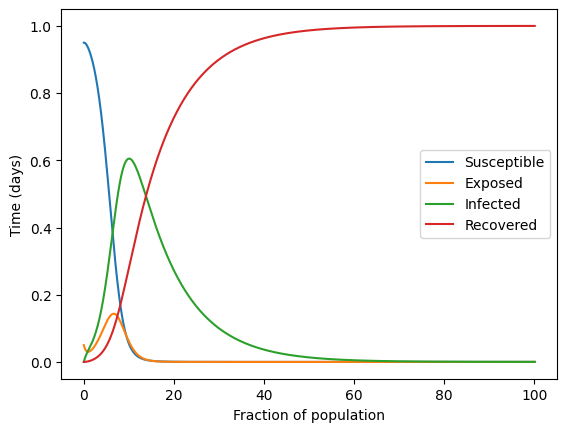

In [69]:
f.forward_euler(**shared_parameters, step=step, t_final=t_final, seir_filename=f_euler_output)
f_euler_df = pd.read_csv(f_euler_output)

fig, ax = plt.subplots()

seir_labels = ["susceptible", "exposed", "infected", "recovered"]

for label in seir_labels:
    ax.plot(f_euler_df.iloc[:,0], f_euler_df[label], label=label.capitalize()) # Plotting each population category on the same ax

ax.set_xlabel("Fraction of population")
ax.set_ylabel("Time (days)")
ax.legend()

plt.show()

### Monte Carlo simulation

In [70]:
sim = mc.System(**shared_parameters, length=length, agent_count=agent_count)
sim.run_sim(MCS=MCS, seir_filename=mc_seir_output, lattice_filename=mc_lattice_output) # Initialising and running sim
mc_seir_df = pd.read_csv(mc_seir_output)

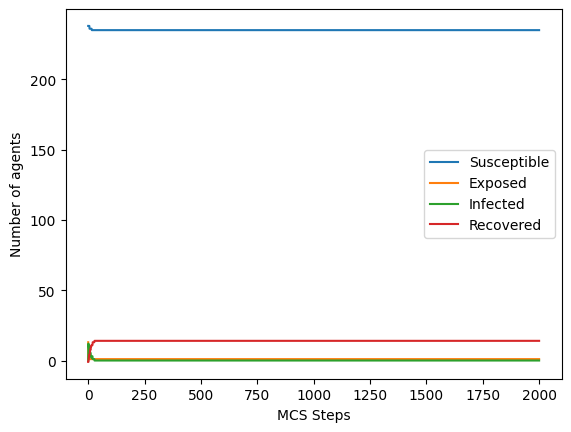

In [71]:
fig, ax = plt.subplots()

seir_labels = ["susceptible", "exposed", "infected", "recovered"]

for label in seir_labels:
    ax.plot(mc_seir_df.iloc[:,0], mc_seir_df[label], label=label.capitalize()) # Plotting each population category on the same ax

ax.set_xlabel("MCS Steps")
ax.set_ylabel("Number of agents")
ax.legend()

plt.show()

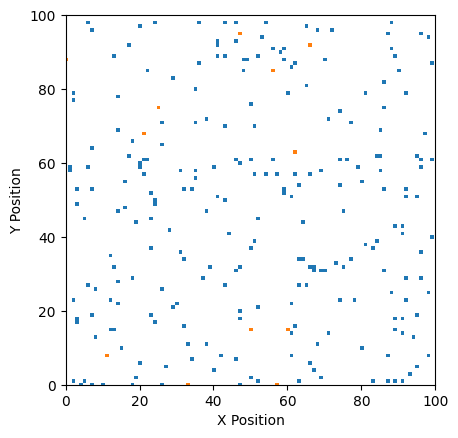

In [74]:
mc_lattice_df = pd.read_csv(mc_lattice_output)

lattices_1d = mc_lattice_df.iloc[:, 1].to_list()
lattices_2d = []

for l in lattices_1d:
    temp = np.array(l.split(), dtype=int)
    l_2d = np.reshape(temp, (length, length))
    lattices_2d.append(l_2d)

fig, ax = plt.subplots()

cmap = colors.ListedColormap(['white', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
norm = colors.NoNorm()

ax.imshow(lattices_2d[0], interpolation='none', cmap=cmap, norm=norm)
ax.set_xlim(0, length)
ax.set_ylim(0, length)
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

plt.show()